# ED of the S=1 quantum-link Schwinger model

This notebook is a small-scale, ED suite for S=1 QLM. 
Unlike some implementations which impose Gauss Law as a penalty, here we impose it exactly. Matter occupations are not independently enumerated: they are reconstructed from Gauss's law. Both open (OBC) and periodic (PBC) boundary conditions are supported.

We use staggered fermions and spin-1 links,

$$H=-t\sum_n( c_n^\dagger S_n^+c_{n+1}+\mathrm{h.c.})+m\sum_n(-1)^n N_n+\frac{g^2}{2}\sum_\ell E_\ell^2,$$

with $E_\ell=S^z_\ell\in\{-1,0,1\}$ and

$$G_n=E_n-E_{n-1}-N_n+q_n=0,~~q_n=\frac{1-(-1)^n}{2}.$$

The spin matrix element is retained: $\langle E+1|S^+|E\rangle=\sqrt{S(S+1)-E(E+1)}$ with $S=1$.

## Boundary conventions

- **OBC:** there are $L$ matter sites, $L-1$ dynamical links, and fixed external fluxes `e_left` and `e_right`. Gauss's law is imposed at every site. Only dynamical links enter the electric energy; fixed-boundary contributions would be an irrelevant constant. The hopping sum runs over $n=0,\ldots,L-2$.

  $e_{\mathrm L}$ -- site $0$ -- $E_0$ -- site $1$ -- $\cdots$ -- $E_{L-2}$ -- site $L-1$ -- $e_{\mathrm R}$
 
- **PBC:** there are $L$ matter sites and $L$ dynamical links. Link $n$ joins matter sites $n$ and $(n+1)\bmod L$. Gauss's law and hopping are periodic.

With OBC, summing Gauss's law fixes the total fermion number through the two boundary fluxes. With PBC it fixes $N_f=\sum_n q_n=L/2$ for even $L$ (half filling).

In [2]:
from dataclasses import dataclass
from itertools import product
from math import sqrt
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

SPIN = 1
E_VALUES = tuple(range(-SPIN, SPIN + 1))

@dataclass(frozen=True)
class GaugeState:
    # E: Electric fluxes on links, N: matter occupations.
    E: tuple
    N: tuple

# definition of the staggered factor
def background(n):
    return (1 - (-1)**n) // 2

# raising and lowering operators
def spin_ladder(E, direction, S=SPIN):
    """Matrix element of S^+ (direction=+1) or S^- (direction=-1)."""
    if direction == +1:
        return sqrt(S * (S + 1) - E * (E + 1))
    return sqrt(S * (S + 1) - E * (E - 1))

In [3]:
def basis_obc(L, e_left=0, e_right=0):
    """Gauge-invariant OBC basis with L sites and L-1 dynamical links.

    Starting from E_{-1}=e_left, choose N_n in {0,1} and use
    E_n - E_{n-1} = N_n - b_n (div.E = rho).  The final generated flux must equal
    e_right.  This recursive construction never visits unphysical states.
    """
    if L < 1 or e_left not in E_VALUES or e_right not in E_VALUES:
        raise ValueError('L >= 1 and spin-1 boundary fluxes are required')
    states = []
    def extend(n, previous_E, fields, occupations):
        if n == L:
            if previous_E == e_right:
                states.append(GaugeState(tuple(fields), tuple(occupations)))
            return
        for occ in (0, 1):
            next_E = previous_E + occ - background(n)
            if n == L - 1:
                if next_E == e_right:
                    extend(n + 1, next_E, fields, occupations + [occ])
            elif next_E in E_VALUES:
                extend(n + 1, next_E, fields + [next_E], occupations + [occ])
    extend(0, e_left, [], [])
    return states

def basis_pbc(L):
    """Gauge-invariant PBC basis with L sites and L links."""
    if L < 2:
        raise ValueError('PBC requires L >= 2')
    states = []
    for fields in product(E_VALUES, repeat=L):
        occ = tuple(fields[n] - fields[(n - 1) % L] + background(n) for n in range(L))
        if all(x in (0, 1) for x in occ):
            states.append(GaugeState(tuple(fields), occ))
    return states

def gauss_residual(state, bc, e_left=0, e_right=0):
    L = len(state.N)
    if bc == 'pbc':
        return np.array([state.E[n] - state.E[(n-1) % L] - state.N[n] + background(n) for n in range(L)])
    extended = (e_left,) + state.E + (e_right,)
    return np.array([extended[n+1] - extended[n] - state.N[n] + background(n) for n in range(L)])

for bc, states in [('obc', basis_obc(4)), ('pbc', basis_pbc(4))]:
    assert all(np.all(gauss_residual(s, bc) == 0) for s in states)
    print(f'{bc.upper()}, L=4: dimension = {len(states)}')

OBC, L=4: dimension = 6
PBC, L=4: dimension = 13


In [9]:
# using different functions
print(basis_obc(4))
print(basis_obc(4)[0])
print(basis_obc(4)[0].E)
print(basis_obc(4)[0].E[0],' ',basis_obc(4)[0].E[1])

[GaugeState(E=(0, -1, 0), N=(0, 0, 1, 1)), GaugeState(E=(0, 0, 0), N=(0, 1, 0, 1)), GaugeState(E=(0, 0, 1), N=(0, 1, 1, 0)), GaugeState(E=(1, 0, 0), N=(1, 0, 0, 1)), GaugeState(E=(1, 0, 1), N=(1, 0, 1, 0)), GaugeState(E=(1, 1, 1), N=(1, 1, 0, 0))]
GaugeState(E=(0, -1, 0), N=(0, 0, 1, 1))
(0, -1, 0)
0   -1


## Sparse Hamiltonian

The diagonal terms are evaluated directly. A hopping event $c_n^\dagger S_n^+c_{n+1}$ maps $(N_n,N_{n+1})=(0,1)$ to $(1,0)$ and raises $E_n$ by one. Its Hermitian conjugate performs the reverse process and lowers $E_n$. These moves preserve Gauss's law exactly. For PBC, the wrap-around fermion hop carries the usual Fock-space sign $(-1)^{N_f-1}$; internal nearest-neighbor hops have unit fermionic sign.

In [10]:
def build_hamiltonian(states, t=1.0, m=0.0, g2=0.0, bc='obc'):
    """Return the CSR Hamiltonian and the state-to-index dictionary."""
    if bc not in ('obc', 'pbc'):
        raise ValueError("bc must be 'obc' or 'pbc'")
    index = {state: i for i, state in enumerate(states)}
    if len(index) != len(states):
        raise ValueError('basis contains duplicate states')
    L = len(states[0].N) if states else 0
    rows, cols, data = [], [], []

    for i, state in enumerate(states):
        diagonal = m * sum(((-1)**n) * state.N[n] for n in range(L))
        diagonal += 0.5 * g2 * sum(E * E for E in state.E)
        rows.append(i); cols.append(i); data.append(diagonal)

        number_of_hops = L if bc == 'pbc' else L - 1
        for link in range(number_of_hops):
            left, right = link, (link + 1) % L
            E = state.E[link]
            # Periodic boundary hop crosses the chosen fermionic ordering cut.
            fsign = (-1)**(sum(state.N) - 1) if (bc == 'pbc' and link == L-1) else 1
            # (0,S,1) ----> (1,S+1,0)
            if state.N[left] == 0 and state.N[right] == 1 and E < SPIN:
                new_E, new_N = list(state.E), list(state.N)
                new_E[link] += 1; new_N[left], new_N[right] = 1, 0
                target = GaugeState(tuple(new_E), tuple(new_N))
                rows.append(index[target]); cols.append(i)
                data.append(-t * fsign * spin_ladder(E, +1))
            # (1,S,0) ----> (0,S-1,1)
            if state.N[left] == 1 and state.N[right] == 0 and E > -SPIN:
                new_E, new_N = list(state.E), list(state.N)
                new_E[link] -= 1; new_N[left], new_N[right] = 0, 1
                target = GaugeState(tuple(new_E), tuple(new_N))
                rows.append(index[target]); cols.append(i)
                data.append(-t * fsign * spin_ladder(E, -1))

    H = sp.coo_matrix((data, (rows, cols)), shape=(len(states), len(states)), dtype=float).tocsr()
    # codex says it is safe to add duplicates
    H.sum_duplicates()
    return H, index

def exact_spectrum(H):
    return np.linalg.eigvalsh(H.toarray())

def lowest_eigenpairs(H, k=6):
    if H.shape[0] <= k + 1:
        vals, vecs = np.linalg.eigh(H.toarray())
        return vals[:k], vecs[:, :k]
    vals, vecs = spla.eigsh(H, k=k, which='SA')
    order = np.argsort(vals)
    return vals[order], vecs[:, order]

In [11]:
# Structural tests: Hermiticity and exact preservation of the physical basis.
for bc, states in [('obc', basis_obc(6)), ('pbc', basis_pbc(6))]:
    H, _ = build_hamiltonian(states, t=1.0, m=0.5, g2=1.0, bc=bc)
    hermiticity_error = spla.norm(H - H.getH())
    assert hermiticity_error < 1.e-12
    print(f'{bc.upper()}: dim={len(states):4d}, nnz={H.nnz:5d}, ||H-H†||={hermiticity_error:.1e}')

OBC: dim=  19, nnz=   77, ||H-H†||=0.0e+00
PBC: dim=  38, nnz=  170, ||H-H†||=0.0e+00


## Example spectra

OBC and PBC are different finite-size Hamiltonians, so their individual eigenvalues need not agree. The cell below plots the lowest levels for the same couplings. Use even $L$ for the conventional staggered vacuum and clean half filling.

OBC: dimension=61, E0=-6.535217713230, gap=2.252457021051
PBC: dimension=117, E0=-6.991488741433, gap=2.064980413012


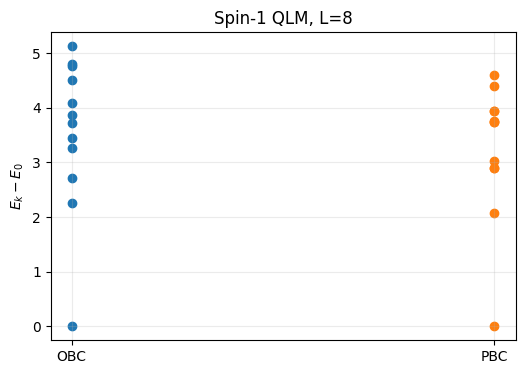

In [12]:
L = 8
parameters = dict(t=1.0, m=0.5, g2=1.0)
results = {}
for bc in ('obc', 'pbc'):
    states = basis_obc(L, e_left=0, e_right=0) if bc == 'obc' else basis_pbc(L)
    H, index = build_hamiltonian(states, bc=bc, **parameters)
    evals, evecs = lowest_eigenpairs(H, k=min(12, len(states)))
    results[bc] = dict(states=states, H=H, evals=evals, evecs=evecs)
    print(f'{bc.upper()}: dimension={len(states)}, E0={evals[0]:.12f}, gap={evals[1]-evals[0]:.12f}')

fig, ax = plt.subplots(figsize=(6, 4))
for x, bc in enumerate(('obc', 'pbc')):
    excitation = results[bc]['evals'] - results[bc]['evals'][0]
    ax.scatter(np.full_like(excitation, x, dtype=float), excitation, label=bc.upper())
ax.set(xticks=[0, 1], xticklabels=['OBC', 'PBC'], ylabel=r'$E_k-E_0$', title=f'Spin-1 QLM, L={L}')
ax.grid(alpha=0.25)
plt.show()

## Diagonal observables

The reduced basis makes gauge-invariant diagonal observables simple. Below are site-resolved $\langle N_n\rangle$, link-resolved $\langle E_\ell\rangle$ and $\langle E_\ell^2\rangle$, the staggered density, and the electric energy density.

In [13]:
def diagonal_expectation(states, psi, values):
    probabilities = np.abs(psi)**2
    return np.tensordot(probabilities, np.asarray([values(s) for s in states]), axes=(0, 0))

def measure_ground_state(result):
    states, psi = result['states'], result['evecs'][:, 0]
    density   = diagonal_expectation(states, psi, lambda s: np.asarray(s.N, float))
    electric  = diagonal_expectation(states, psi, lambda s: np.asarray(s.E, float))
    electric2 = diagonal_expectation(states, psi, lambda s: np.asarray(s.E, float)**2)
    staggered_density = sum(((-1)**n) * density[n] for n in range(len(density))) / len(density)
    return dict(N=density, E=electric, E2=electric2, staggered_N=staggered_density)

for bc in ('obc', 'pbc'):
    obs = measure_ground_state(results[bc])
    print(f'\n{bc.upper()} ground state')
    print('<N_n>  =', np.round(obs['N'], 8))
    print('<E_l>  =', np.round(obs['E'], 8))
    print('<E_l²> =', np.round(obs['E2'], 8))
    print('staggered density =', obs['staggered_N'])


OBC ground state
<N_n>  = [0.19869519 0.69736874 0.25509633 0.72775418 0.27224582 0.74490367
 0.30263126 0.80130481]
<E_l>  = [ 0.19869519 -0.10393608  0.15116026 -0.12108556  0.15116026 -0.10393608
  0.19869519]
<E_l²> = [0.19869519 0.11079793 0.15364947 0.12640402 0.15364947 0.11079793
 0.19869519]
staggered density = -0.24283284866879695

PBC ground state
<N_n>  = [0.26822425 0.73177575 0.26822425 0.73177575 0.26822425 0.73177575
 0.26822425 0.73177575]
<E_l>  = [ 0.13411212 -0.13411212  0.13411212 -0.13411212  0.13411212 -0.13411212
  0.13411212 -0.13411212]
<E_l²> = [0.13817467 0.13817467 0.13817467 0.13817467 0.13817467 0.13817467
 0.13817467 0.13817467]
staggered density = -0.23177575147126542


## Parameter scans and export

The helper below scans the mass without rebuilding the basis. Results are saved in a plain NumPy archive, which is convenient for later comparison with MPS ground-state energies and observables.

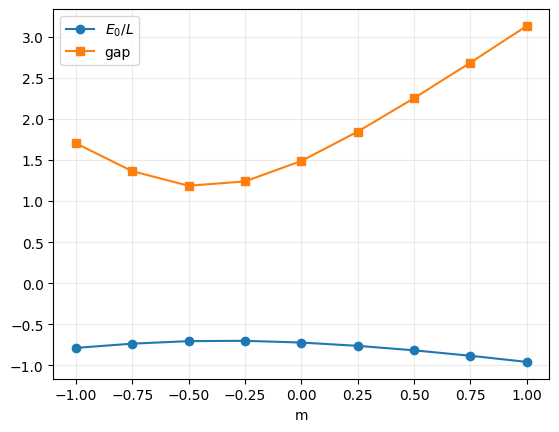

In [14]:
def mass_scan(L, masses, t=1.0, g2=1.0, bc='obc', e_left=0, e_right=0):
    states = basis_obc(L, e_left, e_right) if bc == 'obc' else basis_pbc(L)
    ground, gap = [], []
    for mass in masses:
        H, _ = build_hamiltonian(states, t=t, m=mass, g2=g2, bc=bc)
        values, _ = lowest_eigenpairs(H, k=2)
        ground.append(values[0]); gap.append(values[1] - values[0])
    return np.asarray(ground), np.asarray(gap)

masses = np.linspace(-1.0, 1.0, 9)
ground, gap = mass_scan(8, masses, bc='obc')
# Uncomment to export after choosing production parameters:
# np.savez('spin1_qlm_ed_obc_L8.npz', L=8, masses=masses, E0=ground, gap=gap)
plt.plot(masses, ground / 8, 'o-', label=r'$E_0/L$')
plt.plot(masses, gap, 's-', label='gap')
plt.xlabel('m'); plt.legend(); plt.grid(alpha=0.25); plt.show()

## Matching a future OBC MPS calculation

For a direct comparison, the MPS implementation should use the same geometry: $L$ matter sites, only $L-1$ dynamical spin-1 links, fixed `e_left` and `e_right`, and exact Gauss-law enforcement (or a penalty large enough that extrapolation in the penalty is controlled). It must also use the same $S^\pm$ normalization, so an allowed spin-1 hop has amplitude $-t\sqrt{2}$, not $-t$. Compare in this order:

1. Hilbert-space sector and boundary fluxes.
2. Ground-state energy and energy per matter site.
3. $\langle G_n^2\rangle$ (identically zero here), $\langle N_n\rangle$, and $\langle E_\ell^2\rangle$.
4. The first gap, if an excited-state MPS calculation is available.

The current `../MPS/codes/spin1QLM-dmrg.py` has $L$ link sites and imposes Gauss's law and the right boundary through finite penalties, so its reported energy is not yet directly comparable to this exact OBC Hamiltonian.